<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/Binary_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings

warnings.filterwarnings("ignore")

# Pytorch Model

In [ ]:
import torch

torch.__version__

'2.10.0+cpu'

In [ ]:
import kagglehub

path = kagglehub.dataset_download("rsadiq/salary")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'salary' dataset.
Path to dataset files: /kaggle/input/salary


In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/salary/Salary.csv")
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
df.describe()

,YearsExperience,Salary
count,35.000000,35.000000
mean,6.308571,83945.600000
std,3.618610,32162.673003
min,1.100000,37731.000000
25%,3.450000,57019.000000
50%,5.300000,81363.000000
75%,9.250000,113223.500000
max,13.500000,139465.000000


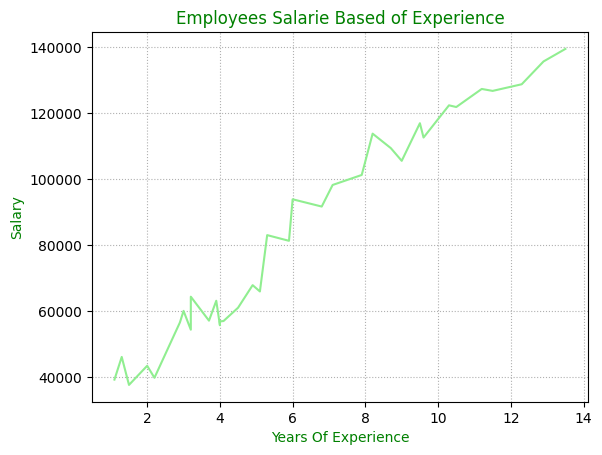

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df['YearsExperience'], df['Salary'], c='lightgreen')
plt.title("Employees Salarie Based of Experience", c='green')
plt.grid(linestyle='dotted')
plt.xlabel("Years Of Experience", c='green')
plt.ylabel("Salary", c='green')
plt.show()

In [ ]:
X = df['YearsExperience']
Y = df['Salary']

In [ ]:
X.values

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5, 11.2, 11.5, 12.3,
       12.9, 13.5])

In [86]:
import numpy as np

ye = np.array(X.values).reshape(-1, 1)
ye[:5]

array([[1.1],
       [1.3],
       [1.5],
       [2. ],
       [2.2]])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 10))
years = scaler.fit_transform(ye)

In [85]:
years[:5]

array([[0.        ],
       [0.16129032],
       [0.32258065],
       [0.72580645],
       [0.88709677]])

In [ ]:
input_tensor = torch.Tensor(years)
output_tensor = torch.Tensor(Y)

In [ ]:
from torch import nn

In [ ]:
class RegressionModel(nn.Module):
  def __init__(self, input_f, output_f):
    super().__init__()
    self.layer = nn.Linear(in_features=input_f, out_features=output_f)
  def forward(self, x):
    return self.layer(x)

In [84]:
input_tensor[:5]

tensor([[0.0000],
        [0.1613],
        [0.3226],
        [0.7258],
        [0.8871]])

In [ ]:
output_tensor

tensor([ 39343.,  46205.,  37731.,  43525.,  39891.,  56642.,  60150.,  54445.,
         64445.,  57189.,  63218.,  55794.,  56957.,  57081.,  61111.,  67938.,
         66029.,  83088.,  81363.,  93940.,  91738.,  98273., 101302., 113812.,
        109431., 105582., 116969., 112635., 122391., 121872., 127345., 126756.,
        128765., 135675., 139465.])

In [ ]:
input = 1
output = 1

In [ ]:
model = RegressionModel(input_f=input, output_f=output)
model

RegressionModel(
  (layer): Linear(in_features=1, out_features=1, bias=True)
)

In [65]:
from torch.optim import SGD
from torch.nn import L1Loss

optimizer = SGD(params=model.parameters(), lr=0.1)
criterion = L1Loss()

In [68]:
for epoch in range(100000):
  model.train()
  pred = model(input_tensor.unsqueeze(1))
  loss = criterion(output_tensor.unsqueeze(1), pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 10000 == 0:
    print(f"Loss: {loss:.5f}")

Loss: 47520.39062
Loss: 46292.46094
Loss: 45680.14844
Loss: 45318.25781
Loss: 45062.47656
Loss: 44857.08984
Loss: 44672.11719
Loss: 44496.47656
Loss: 44326.70703
Loss: 44159.32422


In [74]:
import math

In [69]:
user_input = torch.Tensor([4.8])
user_input

tensor([4.8000])

In [77]:
with torch.inference_mode():
  pred = model(user_input)

prediction = math.ceil(pred)
prediction

67723

In [78]:
user_input2 = torch.Tensor([2.1])
user_input2

tensor([2.1000])

In [79]:
with torch.inference_mode():
  pred2 = model(user_input2)

prediction2 = math.ceil(pred2)
prediction2

33843

In [80]:
user_input3 = torch.Tensor([9.0])

with torch.inference_mode():
  pred3 = model(user_input3)

prediction3 = math.ceil(pred3)
prediction3

120426

In [83]:
user_input4 = torch.Tensor([0.5])

with torch.inference_mode():
  pred4 = model(user_input4)

prediction4 = math.ceil(pred4)
prediction4

13766

# Tensorflow Model

In [87]:
import tensorflow.keras as tf

In [91]:
model2 = tf.Sequential()
model2.add(tf.layers.Dense(units=1, input_shape=[1]))

In [92]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [93]:
model2.compile(optimizer='sgd', loss='mean_squared_error')

In [105]:
model2.fit(years, Y, epochs=1000)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 45749536.0000
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 36063724.0000
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 45334928.0000
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 45506440.0000
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 61374420.0000
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 40670668.0000
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 35206992.0000
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 35047948.0000
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 38281948.0000
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 38313360.0000


In [109]:
exp = [1.0, 2.0, 3.0,4.0,5.0,6.0,7.0,8.0]

test_df = pd.DataFrame(exp, columns=['YearsExperience'])
test_df

,YearsExperience
0,1.0
1,2.0
2,3.0
3,4.0
4,5.0
5,6.0
6,7.0
7,8.0


In [112]:
scaled_test_exp = scaler.transform(np.array(test_df['YearsExperience']).reshape(-1, 1))
scaled_test_exp

array([[-0.08064516],
       [ 0.72580645],
       [ 1.53225806],
       [ 2.33870968],
       [ 3.14516129],
       [ 3.9516129 ],
       [ 4.75806452],
       [ 5.56451613]])

In [113]:
predz = model2.predict(scaled_test_exp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


In [114]:
print(predz)

[[28366.16 ]
 [35721.535]
 [43076.906]
 [50432.28 ]
 [57787.656]
 [65143.03 ]
 [72498.41 ]
 [79853.78 ]]


In [122]:
val = predz.ravel()
val

array([28366.16 , 35721.535, 43076.906, 50432.28 , 57787.656, 65143.03 ,
       72498.41 , 79853.78 ], dtype=float32)

In [124]:
values = [math.ceil(x) for x in val]
values

[28367, 35722, 43077, 50433, 57788, 65144, 72499, 79854]

In [125]:
test_df["Salary"] = values

In [126]:
test_df

,YearsExperience,Salary
0,1.0,28367
1,2.0,35722
2,3.0,43077
3,4.0,50433
4,5.0,57788
5,6.0,65144
6,7.0,72499
7,8.0,79854
